In [13]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

def load_halo_masses_camels(h5_file):
    """ Load FoF halo masses from CAMELS group catalog (Group/GroupMass),converting to Msun/h."""
    with h5py.File(h5_file, "r") as f:
        # GroupMass is in units of 1e10 Msun/h
        masses = f['Group/GroupMass'][:] * 1e10  # now in Msun/h
    masses = masses[masses > 0]
    return masses

def compute_halo_mass_function(masses, boxsize, logM_min=1.0, logM_max=15.0, dlogM=0.5):
    volume = boxsize**3  # (Mpc/h)^3
    logM = np.log10(masses)

    bins = np.arange(logM_min, logM_max + dlogM, dlogM)
    hist, edges = np.histogram(logM, bins=bins)

    logM_centers = 0.5 * (edges[:-1] + edges[1:])
    dlogM = edges[1] - edges[0]

    dndlogM = hist / (volume * dlogM)
    dndlogM_error = np.sqrt(hist) / (volume * dlogM)
    return logM_centers, dndlogM,dndlogM_error
    
def plot_halo_mass_function(logM_centers, dndlogM,dndlogM_error, label=None, mass_cut_log10=None, save_path=None):
    M_centers = 10**logM_centers  # Msun/h

    plt.figure(figsize=(7,5))
    plt.errorbar(M_centers, dndlogM, yerr= dndlogM_error, fmt='o', label=label)
    plt.loglog()
    if mass_cut_log10 is not None:
        M_cut = 10**mass_cut_log10
        plt.axvline(M_cut, linestyle='--', label=rf"$M_{{\rm cut}}=10^{{{mass_cut_log10}}}\ M_\odot/h$")

    plt.xlabel(r"$M_{\rm halo}\ \mathrm{[M_\odot/h]}$")
    plt.ylabel(r"$\mathrm{d}n/\mathrm{d}\log_{10}M\ \ [h^3\mathrm{Mpc}^{-3}]$")
    if label is not None or mass_cut_log10 is not None:
        plt.legend(loc='upper left', fontsize='large')
    #plt.grid(True, which="both", ls=":")
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()
    
    


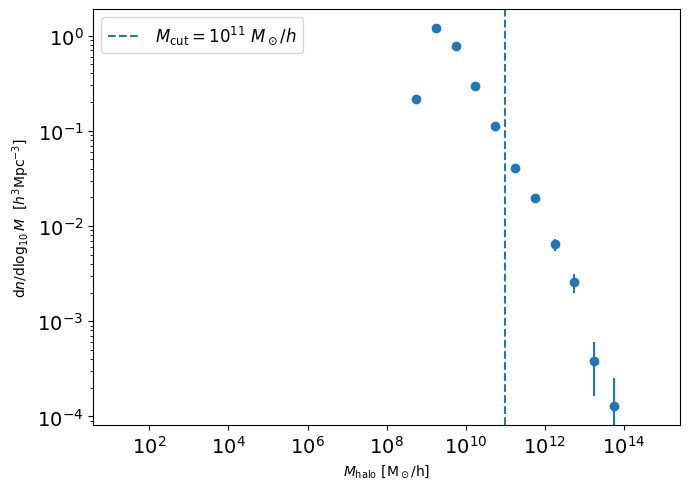

In [14]:

halo_file = "groups_090_1P_0.hdf5" 
Lbox = 25.0  # Mpc/h for CAMELS

masses = load_halo_masses_camels(halo_file)
logM_centers, dndlogM,dndlogM_error = compute_halo_mass_function(masses, boxsize=Lbox)

plot_halo_mass_function(logM_centers, dndlogM,dndlogM_error, mass_cut_log10=11,save_path="halo_mass_function.png")

In [19]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

def load_galaxy_masses_camels(h5_file):
    """
    Load galaxy stellar masses from CAMELS subhalo catalog.
    Uses SubhaloMassType[:,4] (stellar mass).
    Units: 1e10 Msun/h → convert to Msun/h
    """
    with h5py.File(h5_file, "r") as f:
        # index 4 = stellar component (TNG convention)
        masses = f['Subhalo/SubhaloMassType'][:, 4] * 1e10  # Msun/h
    
    masses = masses[masses > 0]  # remove zeros
    return masses


def compute_mass_function(masses, boxsize, logM_min=1.0, logM_max=14.0, dlogM=0.2):
    """
    Generic mass function (works for galaxies or halos)
    """
    volume = boxsize**3  # (Mpc/h)^3
    logM = np.log10(masses)

    bins = np.arange(logM_min, logM_max + dlogM, dlogM)
    hist, edges = np.histogram(logM, bins=bins)

    logM_centers = 0.5 * (edges[:-1] + edges[1:])
    dlogM = edges[1] - edges[0]

    dndlogM = hist / (volume * dlogM)
    dndlogM_error = np.sqrt(hist) / (volume * dlogM)

    return logM_centers, dndlogM, dndlogM_error


def plot_mass_function(logM_centers, dndlogM, dndlogM_error, label=None, mass_cut_log10=None,save_path=None):
    M_centers = 10**logM_centers

    plt.figure(figsize=(7,5))
    plt.errorbar(M_centers, dndlogM, yerr=dndlogM_error, fmt='o', label=label)

    plt.xscale('log')
    plt.yscale('log')

    if mass_cut_log10 is not None:
        M_cut = 10**mass_cut_log10
        plt.axvline(M_cut, linestyle='--',
                    label=rf"$M_{{\rm cut}}=10^{{{mass_cut_log10}}}\ M_\odot/h$")

    plt.xlabel(r"$M_* \ \mathrm{[M_\odot/h]}$")
    plt.ylabel(r"$\mathrm{d}n/\mathrm{d}\log_{10}M_* \ \ [h^3\mathrm{Mpc}^{-3}]$")

    if label is not None or mass_cut_log10 is not None:
        plt.legend(loc='upper left', fontsize='large')

    #plt.grid(True, which="both", ls=":")
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

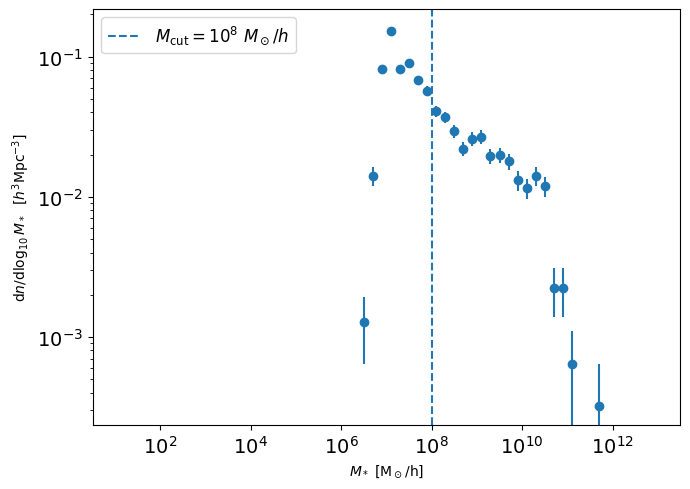

In [20]:
subhalo_file = "groups_090_1P_0.hdf5"
Lbox = 25.0  # Mpc/h

stellar_masses = load_galaxy_masses_camels(subhalo_file)

logM, phi, phi_err = compute_mass_function(
    stellar_masses,
    boxsize=Lbox,
    logM_min=1.0,   # galaxies go lower than halos
    logM_max=13.0,
    dlogM=0.2
)

plot_mass_function(logM, phi, phi_err, mass_cut_log10=8,save_path="stellar_mass_function.png")